# Imports and hyperparms
Essential imports and hyper params for the code

In [20]:
##########################################################
# Imports
##########################################################
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms


##########################################################
# Hyper Parameters
##########################################################

# Dataset transformations/augmentations
ROTATION_DEGREES = 10
MEAN = 0.5
STD = 0.5

# TRAINING
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
LR_DECAY_EPOCS = 5
LR_DECAY_GAMMA = 0.1

# 1. Choose a Dataset
I've chosen to work with Fashion-MNIST

# 2. Data Preparation

In [17]:
# List of classes in the Fashion-MNIST dataset
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# training transoformations
# we augment the data with a horizontal flip, slight rotation to add variation
# and we normalize using mean and standard deviation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),                      # Randomly flip
    transforms.RandomRotation(ROTATION_DEGREES),            # Randomly rotate
    transforms.ToTensor(),                                  # Convert to PyTorch Tensor
    transforms.Normalize((MEAN,), (STD,))                   # Normalize
])

# Test transformations, no augmentations since we want clean test data
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,))
])


# download the dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform_train
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform_test
)

# Dataloarders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. Model Building

In [18]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        
        # Convolution l1
        # (1, 28, 28) -> (32, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        
        # Pooling 
        # (32, 28, 28) -> (32, 14, 14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolution l2
        # (32, 14, 14) -> (64, 14, 14)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Dropout 
        self.dropout = nn.Dropout(p=0.25)
        
        # Fully Connected l1
        # (64 channels) * 7 * 7
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        
        # Fully Connected l2 (output)
        # outputs 10 labels
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Layer 1: Conv, Relu, Pool
        # (N, 1, 28, 28) -> (N, 32, 14, 14)
        x = self.pool(F.relu(self.conv1(x)))
        
        # Layer 2: Conv, Relu, Pool
        # (N, 32, 14, 14) -> (N, 64, 7, 7)
        x = self.pool(F.relu(self.conv2(x)))
        
        # reshape for the FC l1
        # (N, 64*7*7)
        x = x.view(-1, 64 * 7 * 7)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # FC 1
        x = F.relu(self.fc1(x))
        
        # FC 2 (Output)
        x = self.fc2(x)
        return x


model = FashionCNN()
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


# 4. Training

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using: {device}")
model = model.to(device)

# loss function, cross entropy for classification
criterion = nn.CrossEntropyLoss()

# Optimizer, Adam because why not
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate decay, decay by 0.1 ever 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_DECAY_EPOCS, gamma=LR_DECAY_GAMMA)

train_losses = []
val_losses = []

# Training loop
print(f"Starting training, {EPOCHS} epochs in total....\n\n")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate average training loss for the epoch
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    val_accuracy = 100 * correct / total
    
    # Update the learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val Acc: {val_accuracy:.2f}%, "
          f"LR: {current_lr:.6f}")

print("Training Finished!")

using: cpu
Starting training, 10 epochs in total....


Epoch [1/10], Train Loss: 0.4978, Val Loss: 0.3568, Val Acc: 87.14%, LR: 0.001000
Epoch [2/10], Train Loss: 0.3369, Val Loss: 0.3104, Val Acc: 88.79%, LR: 0.001000
Epoch [3/10], Train Loss: 0.2923, Val Loss: 0.2668, Val Acc: 90.38%, LR: 0.001000
Epoch [4/10], Train Loss: 0.2662, Val Loss: 0.2756, Val Acc: 90.20%, LR: 0.001000
Epoch [5/10], Train Loss: 0.2474, Val Loss: 0.2358, Val Acc: 91.49%, LR: 0.000100
Epoch [6/10], Train Loss: 0.2061, Val Loss: 0.2182, Val Acc: 92.14%, LR: 0.000100
Epoch [7/10], Train Loss: 0.1958, Val Loss: 0.2159, Val Acc: 92.43%, LR: 0.000100
Epoch [8/10], Train Loss: 0.1922, Val Loss: 0.2148, Val Acc: 92.48%, LR: 0.000100
Epoch [9/10], Train Loss: 0.1848, Val Loss: 0.2163, Val Acc: 92.46%, LR: 0.000100
Epoch [10/10], Train Loss: 0.1819, Val Loss: 0.2131, Val Acc: 92.58%, LR: 0.000010
Training Finished!


# 5. Evaluation

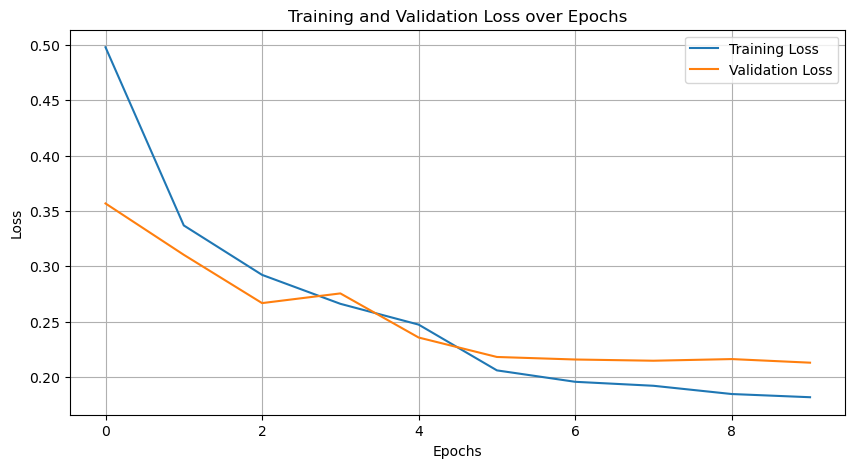

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.87      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.91      0.89      1000
       Dress       0.91      0.94      0.93      1000
        Coat       0.89      0.89      0.89      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.80      0.75      0.78      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



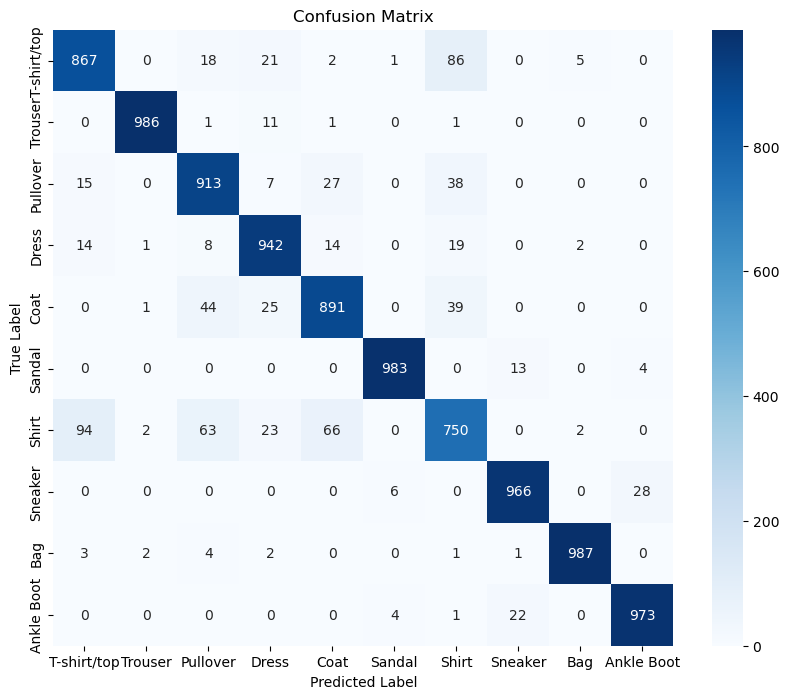

In [22]:
# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation on Test Set 
all_preds = []
all_labels = []
model.eval() # move model to evaluation mode(so it doesn't calculate grads)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# calculate metrics
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# confusion matrix 
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Visualization

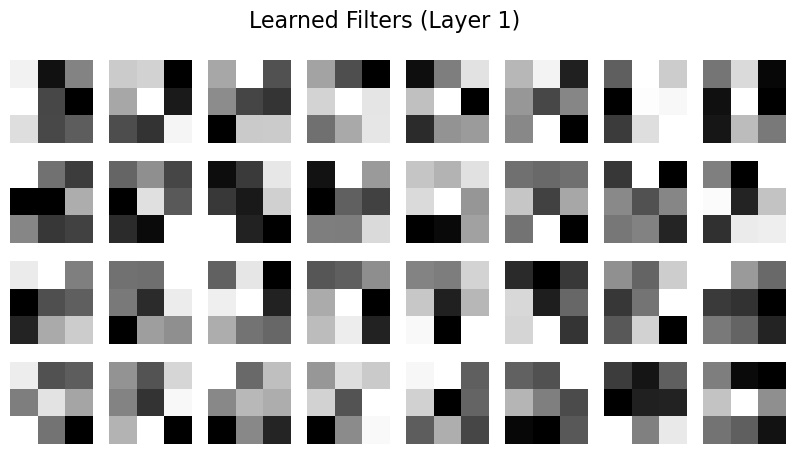

Feature Maps for class: Ankle Boot


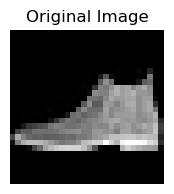

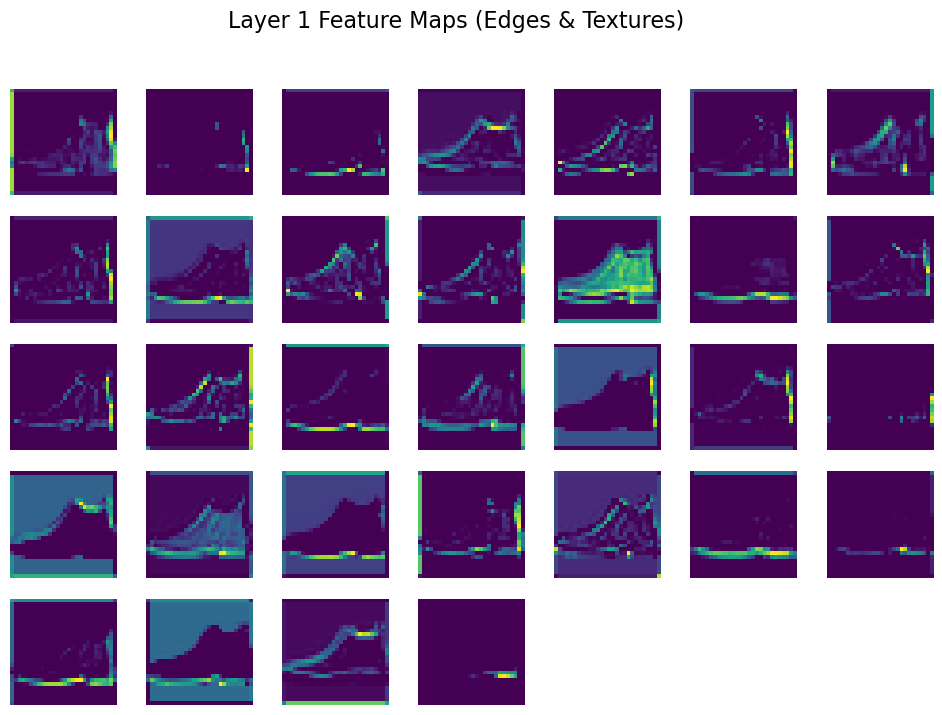

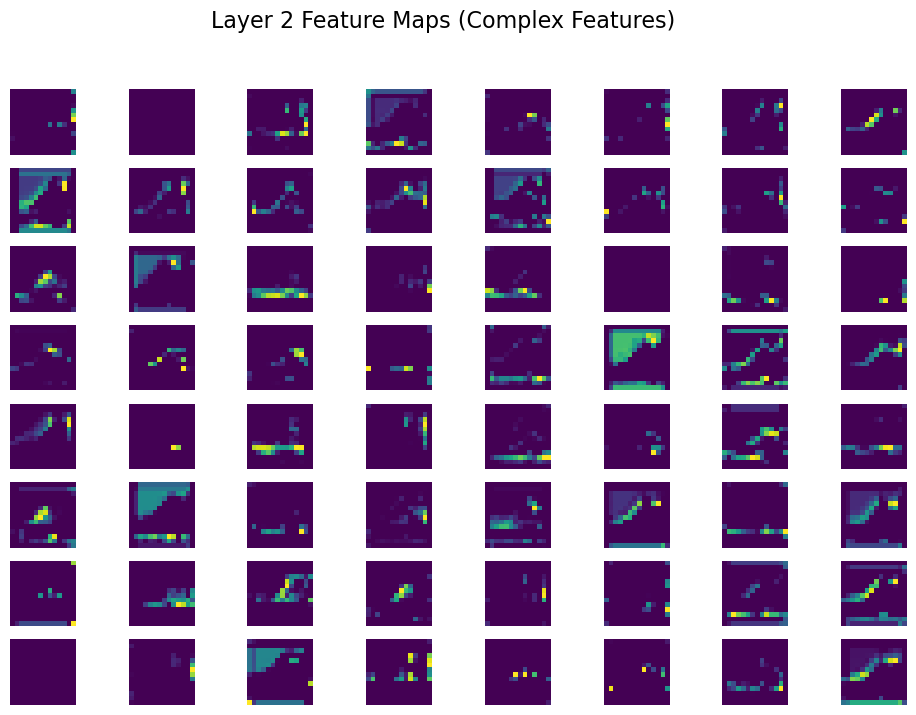

In [24]:
# function to normalize filters for visualization
def normalize_output(img):
    img = img - img.min()
    img = img / img.max()
    return img

# fliters visualization from layer1 of the convelution
kernels = model.conv1.weight.detach().cpu()

plt.figure(figsize=(10, 5))
plt.suptitle("Learned Filters (Layer 1)", fontsize=16)
for i in range(32):  # We have 32 filters in conv1
    plt.subplot(4, 8, i+1)
    plt.imshow(kernels[i, 0, :, :], cmap='gray')
    plt.axis('off')
plt.show()

# feature maps
# get some image, and pass it through the model to see what happens
dataiter = iter(test_loader)
images, labels = next(dataiter)
sample_image = images[0].unsqueeze(0).to(device)  # Add batch dimension

# Pass through Conv1
act1 = model.conv1(sample_image)
act1 = F.relu(act1)  # Apply activation

# Pass through Pool1
pool1 = model.pool(act1)

# Pass through Conv2
act2 = model.conv2(pool1)
act2 = F.relu(act2)

# Plotting function
def plot_maps(maps, title):
    maps = maps.detach().cpu()
    num_maps = maps.shape[1]
    rows = int(np.sqrt(num_maps))
    cols = int(np.ceil(num_maps / rows))
    
    plt.figure(figsize=(12, 8))
    plt.suptitle(title, fontsize=16)
    for i in range(num_maps):
        plt.subplot(rows, cols, i+1)
        plt.imshow(maps[0, i, :, :], cmap='viridis') 
        plt.axis('off')
    plt.show()

print(f"Feature Maps for class: {classes[labels[0]]}")

# show original image
plt.figure(figsize=(2,2))
plt.title("Original Image")
plt.imshow(images[0].permute(1,2,0).cpu().numpy()/2 + 0.5, cmap='gray')
plt.axis('off')
plt.show()

# show the feature maps
plot_maps(act1, "Layer 1 Feature Maps (Edges & Textures)")
plot_maps(act2, "Layer 2 Feature Maps (Complex Features)")